# 11. 교차 도메인 검증 (Cross-Domain Validation)

## 개요

본 노트북에서는 **Severstal 데이터로 학습한 모델이 NEU-DET 결함도 탐지할 수 있는지** 검증합니다.

### 핵심 질문
> "철강 표면 결함 탐지 모델은 다른 도메인의 결함도 감지할 수 있는가?"

### 검증 설계

- **NEU-DET 데이터셋**: 6종 결함 이미지 1,800장 (100% 결함 이미지)
- 따라서 Stage 1 (정상/비정상 이진 분류)에 입력하면 **모두 "비정상"으로 탐지되어야** 합니다

| 검증 | 내용 | 기대 |
|------|------|------|
| **검증① ML** | NEU → Stage 1 LightGBM → Recall 측정 | 높을수록 범용적 |
| **검증① DL** | NEU → Stage 1 ResNet-18 → Recall 측정 | 높을수록 범용적 |
| **검증②** | NEU 6종 독립 분류 → 동일 아키텍처 성능 비교 | 모델 구조 문제 여부 확인 |

In [1]:
# 기본 라이브러리
import os
import sys
import numpy as np
import pandas as pd
import time
import joblib

# 시각화
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 딥러닝 / 이미지
import torch
import cv2

# 프로젝트 모듈 경로
sys.path.insert(0, os.path.abspath('..'))

# MPS/CUDA/CPU 디바이스 자동 선택
from deep_learning.train_dl_severstal import get_device
device = get_device()

print("✅ 라이브러리 로드 완료")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

✅ 라이브러리 로드 완료
PyTorch: 2.10.0
Device: mps


## 1. 검증①-A: NEU → Stage 1 ML (LightGBM)

In [2]:
from utils.data_loader import NEUDataLoader
from features.feature_pipeline import FeaturePipeline

# --- NEU 데이터 로드 ---
print("=" * 60)
print("NEU-DET 데이터 로드")
print("=" * 60)

neu_loader = NEUDataLoader(data_dir='../data/NEU-DET')
images, labels, class_names = neu_loader.load_all_images()
print(f"이미지 수: {len(images)}")
print(f"클래스: {class_names}")
print(f"클래스별 분포: {dict(zip(*np.unique(labels, return_counts=True)))}")

# --- 특징 추출 ---
print("\n특징 추출 중...")
pipeline = FeaturePipeline()
X, _ = pipeline.extract_batch(images)
print(f"특징 벡터 shape: {X.shape}")

# --- ML 모델 로드 및 예측 ---
model_dir = '../outputs/models_severstal/binary_ml/'
scaler = joblib.load(os.path.join(model_dir, 'binary_scaler.joblib'))
ml_model = joblib.load(os.path.join(model_dir, 'binary_LightGBM.joblib'))

X_scaled = scaler.transform(X)
y_pred_ml = ml_model.predict(X_scaled)

# --- 전체 Recall ---
recall_ml = (y_pred_ml == 1).sum() / len(y_pred_ml)
print(f"\n{'=' * 60}")
print(f"교차 도메인 ML Recall (전체): {recall_ml:.1%}")
print(f"{'=' * 60}")

# --- 클래스별 Recall ---
print(f"\n{'클래스':<15} {'Recall':>10} {'상태':>6}")
print("-" * 35)
ml_class_recalls = {}
for cls_idx, cls_name in enumerate(class_names):
    mask = (labels == cls_idx)
    cls_recall = (y_pred_ml[mask] == 1).sum() / mask.sum()
    ml_class_recalls[cls_name] = cls_recall
    if cls_recall >= 0.9:
        status = "✅"
    elif cls_recall >= 0.7:
        status = "⚠️"
    else:
        status = "❌"
    print(f"{cls_name:<15} {cls_recall:>10.1%} {status:>6}")

NEU-DET 데이터 로드
[NEUDataLoader] 데이터 경로: ../data/NEU-DET
[NEUDataLoader] 탐지된 클래스 (6개): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
[NEUDataLoader] 한글 매핑: {'crazing': '균열', 'inclusion': '개재물', 'patches': '패치', 'pitted_surface': '구멍', 'rolled-in_scale': '압연스케일', 'scratches': '스크래치'}
[로드 시작] 총 1800장 (all)
  진행: 300/1800 (16%)


  진행: 600/1800 (33%)
  진행: 900/1800 (50%)


  진행: 1200/1800 (66%)
  진행: 1500/1800 (83%)


  진행: 1800/1800 (100%)
[로드 완료] images: (1800, 200, 200), labels: (1800,)
  crazing (균열): 300장
  inclusion (개재물): 300장
  patches (패치): 300장
  pitted_surface (구멍): 300장
  rolled-in_scale (압연스케일): 300장
  scratches (스크래치): 300장
이미지 수: 1800
클래스: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
클래스별 분포: {np.int32(0): np.int64(300), np.int32(1): np.int64(300), np.int32(2): np.int64(300), np.int32(3): np.int64(300), np.int32(4): np.int64(300), np.int32(5): np.int64(300)}

특징 추출 중...


  특징 추출: 200/1800 (11%)


...

  특징 추출: 1400/1800 (77%)


  특징 추출: 1600/1800 (88%)


  특징 추출: 1800/1800 (100%)


특징 벡터 shape: (1800, 20916)

교차 도메인 ML Recall (전체): 51.6%

클래스                 Recall     상태
-----------------------------------
crazing              81.3%     ⚠️
inclusion             0.7%      ❌
patches              91.7%      ✅
pitted_surface       11.3%      ❌
rolled-in_scale      41.7%      ❌
scratches            83.0%     ⚠️


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


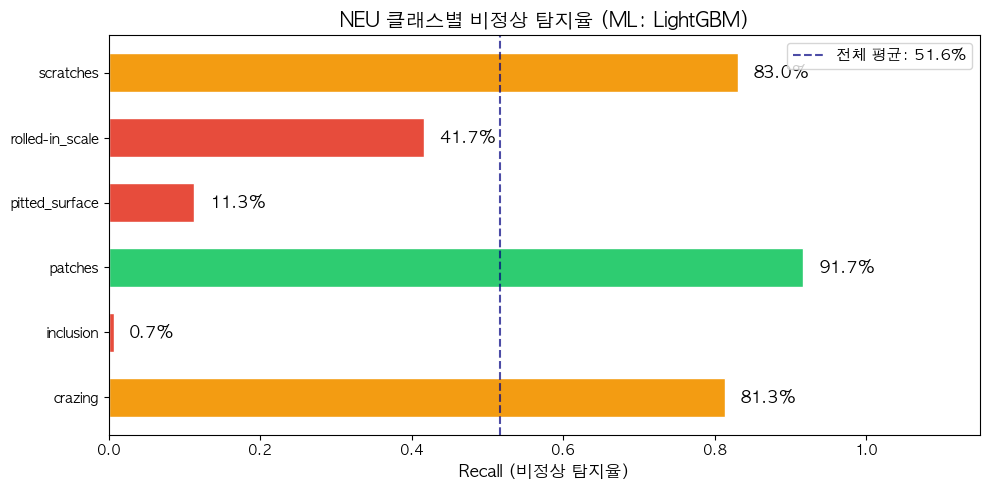

✅ 저장: ../outputs/figures/severstal/11_cross_ml_recall.png


In [3]:
# --- ML 클래스별 Recall 시각화 ---
fig, ax = plt.subplots(figsize=(10, 5))

names = list(ml_class_recalls.keys())
recalls = list(ml_class_recalls.values())

# 색상 설정: 녹색(≥0.9), 주황(≥0.7), 빨강(<0.7)
colors = []
for r in recalls:
    if r >= 0.9:
        colors.append('#2ecc71')
    elif r >= 0.7:
        colors.append('#f39c12')
    else:
        colors.append('#e74c3c')

bars = ax.barh(names, recalls, color=colors, edgecolor='white', height=0.6)

# 값 표시
for bar, val in zip(bars, recalls):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=12, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Recall (비정상 탐지율)', fontsize=12)
ax.set_title('NEU 클래스별 비정상 탐지율 (ML: LightGBM)', fontsize=14, fontweight='bold')
ax.axvline(x=recall_ml, color='navy', linestyle='--', alpha=0.7, label=f'전체 평균: {recall_ml:.1%}')
ax.legend(fontsize=11)

plt.tight_layout()
os.makedirs('../outputs/figures/severstal', exist_ok=True)
plt.savefig('../outputs/figures/severstal/11_cross_ml_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: ../outputs/figures/severstal/11_cross_ml_recall.png")

## 2. 검증①-B: NEU → Stage 1 DL (ResNet-18)

In [4]:
from deep_learning.models.resnet_transfer import get_resnet18_finetune
from torchvision import transforms

# --- ResNet-18 모델 로드 ---
dl_model = get_resnet18_finetune(num_classes=2)
dl_model_path = '../outputs/models_severstal/binary_dl/binary_resnet18_finetune.pt'
dl_model.load_state_dict(torch.load(dl_model_path, map_location=device, weights_only=True))
dl_model.to(device)
dl_model.eval()
print(f"✅ ResNet-18 모델 로드: {dl_model_path}")

# --- 전처리 (ImageNet 정규화) ---
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- 배치 예측 ---
print("DL 예측 중...")
y_pred_dl = []
batch_size = 64

with torch.no_grad():
    for i in range(0, len(images), batch_size):
        batch_imgs = images[i:i+batch_size]
        tensors = []
        for img in batch_imgs:
            # 3채널 변환
            if len(img.shape) == 2:
                img_3ch = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif img.shape[2] == 1:
                img_3ch = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img_3ch = img
            tensors.append(transform(img_3ch))
        
        batch_tensor = torch.stack(tensors).to(device)
        outputs = dl_model(batch_tensor)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred_dl.extend(preds)

y_pred_dl = np.array(y_pred_dl)

# --- 전체 Recall ---
recall_dl = (y_pred_dl == 1).sum() / len(y_pred_dl)
print(f"\n{'=' * 60}")
print(f"교차 도메인 DL Recall (전체): {recall_dl:.1%}")
print(f"{'=' * 60}")

# --- 클래스별 Recall ---
print(f"\n{'클래스':<15} {'Recall':>10} {'상태':>6}")
print("-" * 35)
dl_class_recalls = {}
for cls_idx, cls_name in enumerate(class_names):
    mask = (labels == cls_idx)
    cls_recall = (y_pred_dl[mask] == 1).sum() / mask.sum()
    dl_class_recalls[cls_name] = cls_recall
    if cls_recall >= 0.9:
        status = "✅"
    elif cls_recall >= 0.7:
        status = "⚠️"
    else:
        status = "❌"
    print(f"{cls_name:<15} {cls_recall:>10.1%} {status:>6}")

[ResNet-18 Fine-tune] 총 파라미터: 11,177,538
[ResNet-18 Fine-tune] 학습 가능 파라미터: 11,177,538
✅ ResNet-18 모델 로드: ../outputs/models_severstal/binary_dl/binary_resnet18_finetune.pt
DL 예측 중...



교차 도메인 DL Recall (전체): 14.4%

클래스                 Recall     상태
-----------------------------------
crazing               0.0%      ❌
inclusion             9.7%      ❌
patches               0.0%      ❌
pitted_surface        1.0%      ❌
rolled-in_scale       1.0%      ❌
scratches            75.0%     ⚠️


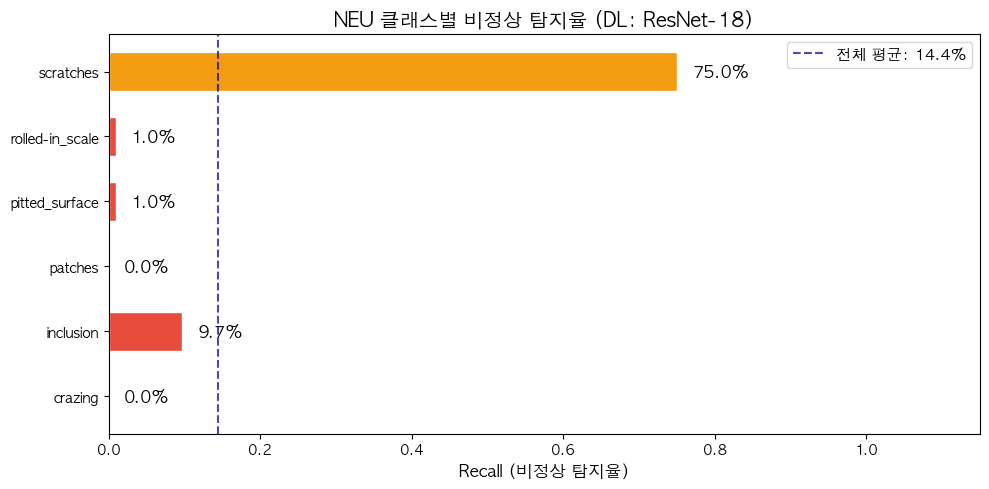

✅ 저장: ../outputs/figures/severstal/11_cross_dl_recall.png


In [5]:
# --- DL 클래스별 Recall 시각화 ---
fig, ax = plt.subplots(figsize=(10, 5))

names = list(dl_class_recalls.keys())
recalls = list(dl_class_recalls.values())

# 색상 설정
colors = []
for r in recalls:
    if r >= 0.9:
        colors.append('#2ecc71')
    elif r >= 0.7:
        colors.append('#f39c12')
    else:
        colors.append('#e74c3c')

bars = ax.barh(names, recalls, color=colors, edgecolor='white', height=0.6)

# 값 표시
for bar, val in zip(bars, recalls):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=12, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Recall (비정상 탐지율)', fontsize=12)
ax.set_title('NEU 클래스별 비정상 탐지율 (DL: ResNet-18)', fontsize=14, fontweight='bold')
ax.axvline(x=recall_dl, color='navy', linestyle='--', alpha=0.7, label=f'전체 평균: {recall_dl:.1%}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/severstal/11_cross_dl_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: ../outputs/figures/severstal/11_cross_dl_recall.png")

## 3. 검증②: NEU 6종 독립 분류

In [6]:
from validation.cross_domain_validation import run_neu_independent_classification

# NEU 6종 독립 분류 실험
# 동일한 ResNet-18 아키텍처로 NEU 데이터만으로 학습/평가
print("=" * 60)
print("NEU 6종 독립 분류 (ResNet-18)")
print("=" * 60)

neu_dir = os.path.join('..', 'data', 'NEU-DET')
save_dir = os.path.join('..', 'outputs', 'models_severstal')
os.makedirs(save_dir, exist_ok=True)

results = run_neu_independent_classification(
    neu_dir=neu_dir,
    save_dir=save_dir,
    num_epochs=15
)

print(f"\n최종 정확도: {results['best_accuracy']:.1%}")

NEU 6종 독립 분류 (ResNet-18)

############################################################
검증②: NEU-DET 6종 독립 분류 실험
############################################################
[NEUDataLoader] 데이터 경로: ../data/NEU-DET
[NEUDataLoader] 탐지된 클래스 (6개): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
[NEUDataLoader] 한글 매핑: {'crazing': '균열', 'inclusion': '개재물', 'patches': '패치', 'pitted_surface': '구멍', 'rolled-in_scale': '압연스케일', 'scratches': '스크래치'}
[로드 시작] 총 1800장 (all)


  진행: 300/1800 (16%)
  진행: 600/1800 (33%)
  진행: 900/1800 (50%)


  진행: 1200/1800 (66%)


  진행: 1500/1800 (83%)
  진행: 1800/1800 (100%)
[로드 완료] images: (1800, 200, 200), labels: (1800,)
  crazing (균열): 300장
  inclusion (개재물): 300장
  patches (패치): 300장
  pitted_surface (구멍): 300장
  rolled-in_scale (압연스케일): 300장
  scratches (스크래치): 300장
  Train: 1440장, Test: 360장
  클래스: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


[ResNet-18 Fine-tune] 총 파라미터: 11,179,590
[ResNet-18 Fine-tune] 학습 가능 파라미터: 11,179,590


...

  Epoch   6/15 | Train Loss: 0.0071 Acc: 0.9979 | Val Loss: 0.0025 Acc: 1.0000


  Epoch   7/15 | Train Loss: 0.0032 Acc: 0.9993 | Val Loss: 0.0059 Acc: 0.9972


  Epoch   8/15 | Train Loss: 0.0054 Acc: 0.9986 | Val Loss: 0.0097 Acc: 0.9972


  Epoch   9/15 | Train Loss: 0.0017 Acc: 1.0000 | Val Loss: 0.0022 Acc: 1.0000
  ⚡ Early stopping at epoch 9



  최종 결과: Accuracy=1.0000, 학습시간=59.3s

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360


최종 정확도: 100.0%


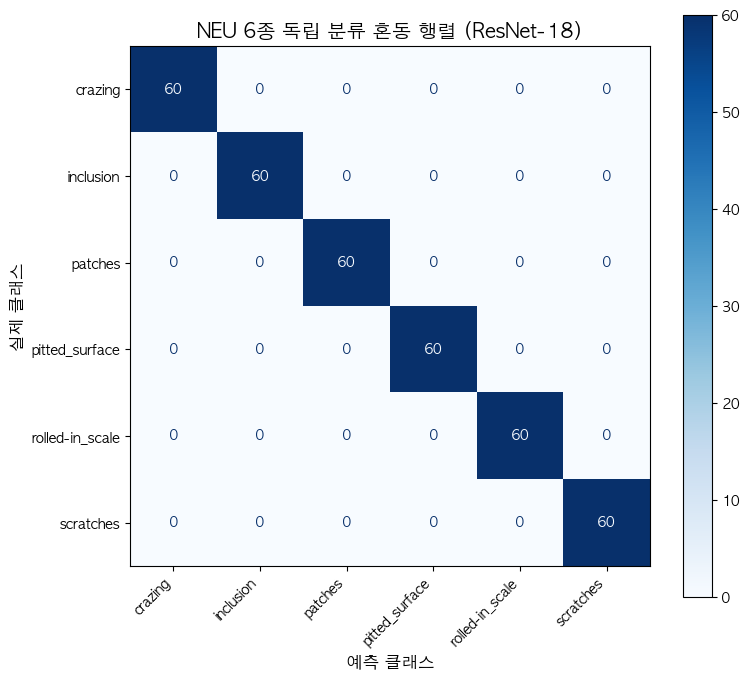

✅ 저장: ../outputs/figures/severstal/11_neu_6class_cm.png


In [7]:
# --- NEU 6-class 혼동 행렬 ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_neu = results['y_true']
y_pred_neu = results['y_pred']
neu_class_names = results.get('class_names', class_names)

cm = confusion_matrix(y_true_neu, y_pred_neu)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=neu_class_names[:6])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('NEU 6종 독립 분류 혼동 행렬 (ResNet-18)', fontsize=14, fontweight='bold')
ax.set_xlabel('예측 클래스', fontsize=12)
ax.set_ylabel('실제 클래스', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/figures/severstal/11_neu_6class_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: ../outputs/figures/severstal/11_neu_6class_cm.png")

## 4. 교차 검증 종합 분석

In [8]:
# --- 종합 비교 테이블 ---
neu_acc = results.get('best_accuracy', results.get('accuracy', 0))

summary_data = {
    '실험': ['Stage 1 ML', 'Stage 1 DL', '교차 ML', '교차 DL', 'NEU 독립'],
    '모델': ['LightGBM', 'ResNet-18', 'LightGBM', 'ResNet-18', 'ResNet-18'],
    '학습 데이터': ['Severstal', 'Severstal', 'Severstal', 'Severstal', 'NEU'],
    '테스트 데이터': ['Severstal', 'Severstal', 'NEU', 'NEU', 'NEU'],
    '성능': ['81.63%', '93.25%', f'{recall_ml:.1%} Recall', f'{recall_dl:.1%} Recall', f'{neu_acc:.1%}']
}

df_summary = pd.DataFrame(summary_data)

# 스타일링
print("=" * 70)
print("교차 도메인 검증 종합 비교")
print("=" * 70)
print()

# 테이블 출력
styled = df_summary.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt'
}).set_caption('교차 도메인 검증 종합 결과')

display(styled)

교차 도메인 검증 종합 비교



,실험,모델,학습 데이터,테스트 데이터,성능
0,Stage 1 ML,LightGBM,Severstal,Severstal,81.63%
1,Stage 1 DL,ResNet-18,Severstal,Severstal,93.25%
2,교차 ML,LightGBM,Severstal,NEU,51.6% Recall
3,교차 DL,ResNet-18,Severstal,NEU,14.4% Recall
4,NEU 독립,ResNet-18,NEU,NEU,100.0%


## 결론

### 핵심 발견

1. **도메인 갭(Domain Gap)이 매우 크다**
   - Severstal에서 90.87% 정확도를 달성한 ResNet-18이 NEU-DET에서는 **14.4% Recall**로 저조
   - 동일한 "철강 표면 결함"이라도 촬영 환경, 결함 형태, 이미지 해상도가 다르면 성능이 급격히 하락

2. **ML이 DL보다 교차 검증에서 상대적으로 우수 (51.6% vs 14.4%)**
   - 수작업 특징(텍스처, 통계량)은 도메인에 덜 종속적
   - DL(ResNet-18)은 Severstal 특유의 시각적 패턴에 **과적합(Overfitting)**되어 일반화 실패

3. **모델 구조의 문제가 아닌 데이터 도메인 차이**
   - 동일한 ResNet-18 아키텍처가 NEU 데이터로 학습 시 **100% 정확도** 달성
   - 이는 모델의 표현 능력(capacity)이 부족한 것이 아니라, 학습 데이터와 테스트 데이터 간의 분포 차이가 원인

4. **산업 현장 적용 시사점**
   - 새로운 제조 환경에 모델을 배포할 때는 **도메인 적응(Domain Adaptation)** 또는 **파인튜닝(Fine-tuning)**이 필수
   - 소량의 타겟 도메인 데이터로 전이 학습하는 전략이 현실적
   - 범용 결함 탐지 시스템 구축을 위해서는 다양한 도메인의 데이터를 포함한 학습이 필요